<a href="https://colab.research.google.com/github/lizzietsitsishvili/ECON3916-Statistical-Machine-Learning/blob/main/Lab%2018/%5BLab_18%5D_Model_Evaluation_%E2%80%94_Metrics_that_Matter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -----------------------------------------------------------
# SETUP — Run this cell first. Install any missing packages.
# -----------------------------------------------------------

# Uncomment if running for the first time:
# !pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Setup complete ✓")

Setup complete ✓


In [4]:
# Step 1: Load data
# Download from Kaggle: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# Place creditcard.csv in the same directory as this notebook, or update the path below.

# Option A: Load from local file
df = pd.read_csv('creditcard.csv')

# Option B (Google Colab): Upload from Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/data/creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean():.4%}")

Dataset shape: (31780, 31)

Class distribution:
Class
0.0    31677
1.0      102
Name: count, dtype: int64

Fraud rate: 0.3210%


In [5]:
# Step 2: Inspect the data — always look before modeling
print("First 5 rows:")
print(df.head())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nTransaction amount stats:")
print(df['Amount'].describe())

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       

In [7]:
# Step 3: Prepare features and target
# Drop 'Time' (not useful for this exercise) and separate X, y

# Drop rows with any NaN values to handle the ValueError in y
df.dropna(inplace=True)

X = df.drop(columns=['Class', 'Time'])
y = df['Class']

# Scale the 'Amount' feature (V1-V28 are already PCA-scaled)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

# Train/test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} transactions ({y_train.sum()} frauds)")
print(f"Test set:     {X_test.shape[0]:,} transactions ({y_test.sum()} frauds)")

Training set: 25,423 transactions (82.0 frauds)
Test set:     6,356 transactions (20.0 frauds)


In [8]:
# Step 4: The naïve baseline — predict "not fraud" for everything
# This demonstrates the accuracy paradox from lecture

naive_predictions = np.zeros(len(y_test))  # All zeros = "not fraud"
naive_accuracy = (naive_predictions == y_test).mean()

print(f"Naïve baseline accuracy: {naive_accuracy:.4%}")
print(f"Naïve baseline recall (fraud class): {recall_score(y_test, naive_predictions):.4%}")
print(f"\n→ 99.83% accuracy, 0% recall. The accuracy paradox in action.")

Naïve baseline accuracy: 99.6853%
Naïve baseline recall (fraud class): 0.0000%

→ 99.83% accuracy, 0% recall. The accuracy paradox in action.


In [9]:
# Step 5: Train a logistic regression classifier
# This is the model from Topic 17 — now we evaluate it properly

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Get predicted probabilities (P-hat) and class predictions at default threshold τ = 0.5
y_prob = log_reg.predict_proba(X_test)[:, 1]  # P(fraud)
y_pred = log_reg.predict(X_test)  # Binary prediction at τ = 0.5

print(f"Model accuracy: {(y_pred == y_test).mean():.4%}")
print(f"\nBut let's look at the confusion matrix...")

Model accuracy: 99.6853%

But let's look at the confusion matrix...


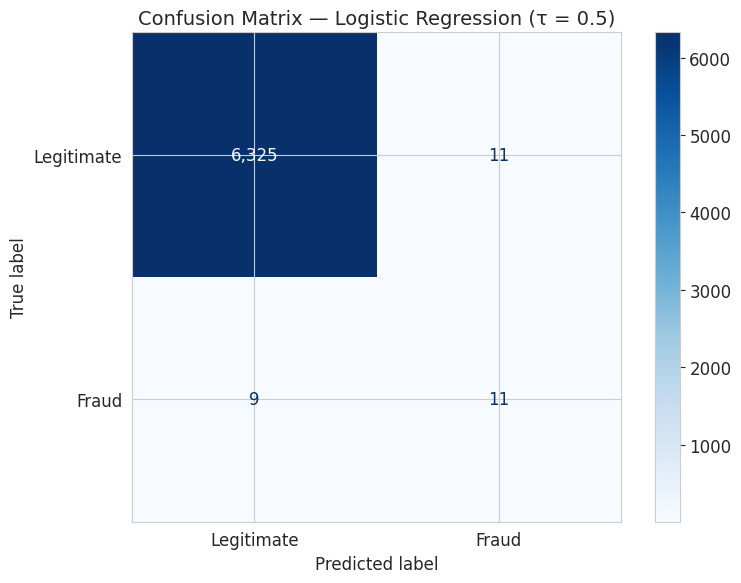

True Positives (fraud caught):     11
False Negatives (fraud missed):     9
False Positives (legit blocked):    11
True Negatives (legit approved):    6,325


In [10]:
# Step 6: Confusion matrix — the real picture

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)', fontsize=14)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (fraud caught):     {tp}")
print(f"False Negatives (fraud missed):     {fn}")
print(f"False Positives (legit blocked):    {fp}")
print(f"True Negatives (legit approved):    {tn:,}")

In [11]:
# Step 7: Classification report — Precision, Recall, F1 per class

print("Classification Report (τ = 0.5):")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
print("\n→ Focus on the FRAUD row. That's the class that matters.")
print("→ 'macro avg' = unweighted mean across classes.")
print("→ 'weighted avg' = weighted by class size (dominated by majority class — just like accuracy).")

Classification Report (τ = 0.5):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      6336
       Fraud       0.50      0.55      0.52        20

    accuracy                           1.00      6356
   macro avg       0.75      0.77      0.76      6356
weighted avg       1.00      1.00      1.00      6356


→ Focus on the FRAUD row. That's the class that matters.
→ 'macro avg' = unweighted mean across classes.
→ 'weighted avg' = weighted by class size (dominated by majority class — just like accuracy).


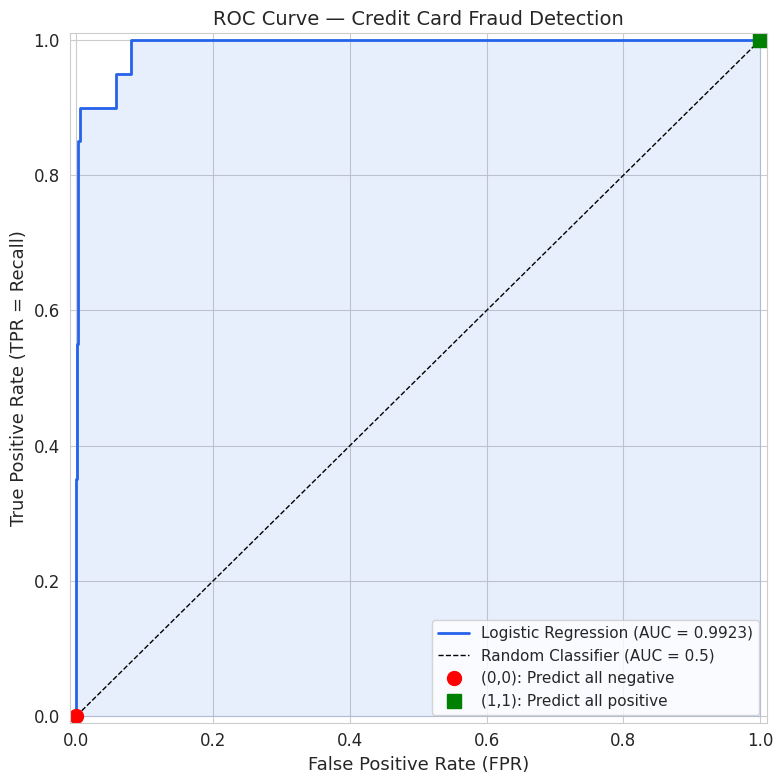

AUC = 0.9923

Interpretation: There is a 99.2% probability that the model
ranks a random fraud transaction higher than a random legitimate transaction.


In [12]:
# Step 1: Plot the ROC curve

fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, color='#2563eb', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2563eb')

# Mark key reference points
ax.plot(0, 0, 'ro', markersize=10, label='(0,0): Predict all negative')
ax.plot(1, 1, 'gs', markersize=10, label='(1,1): Predict all positive')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=13)
ax.set_ylabel('True Positive Rate (TPR = Recall)', fontsize=13)
ax.set_title('ROC Curve — Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

print(f"AUC = {auc_score:.4f}")
print(f"\nInterpretation: There is a {auc_score:.1%} probability that the model")
print(f"ranks a random fraud transaction higher than a random legitimate transaction.")

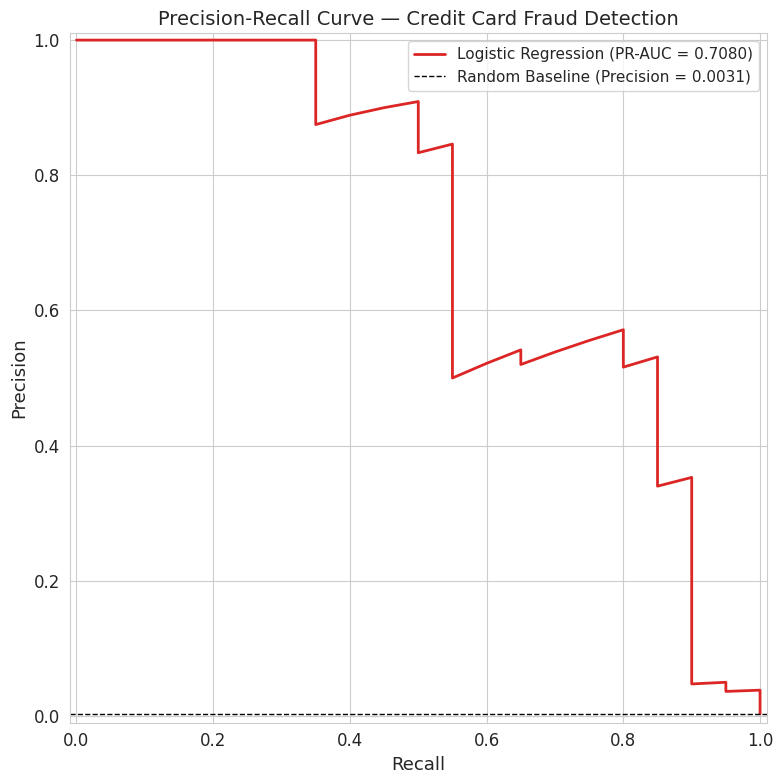

PR-AUC = 0.7080

Notice: The PR curve is much harder to look 'good' on than the ROC curve.
That's because it ignores TN — it focuses entirely on fraud-class performance.


In [13]:
# Step 2: Plot the Precision-Recall curve
# For highly imbalanced data, the PR curve is often more informative than ROC

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_vals, precision_vals)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(recall_vals, precision_vals, color='#dc2626', linewidth=2,
        label=f'Logistic Regression (PR-AUC = {pr_auc:.4f})')

# Baseline: random classifier precision = positive class prevalence
baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1,
           label=f'Random Baseline (Precision = {baseline:.4f})')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve — Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

print(f"PR-AUC = {pr_auc:.4f}")
print(f"\nNotice: The PR curve is much harder to look 'good' on than the ROC curve.")
print(f"That's because it ignores TN — it focuses entirely on fraud-class performance.")

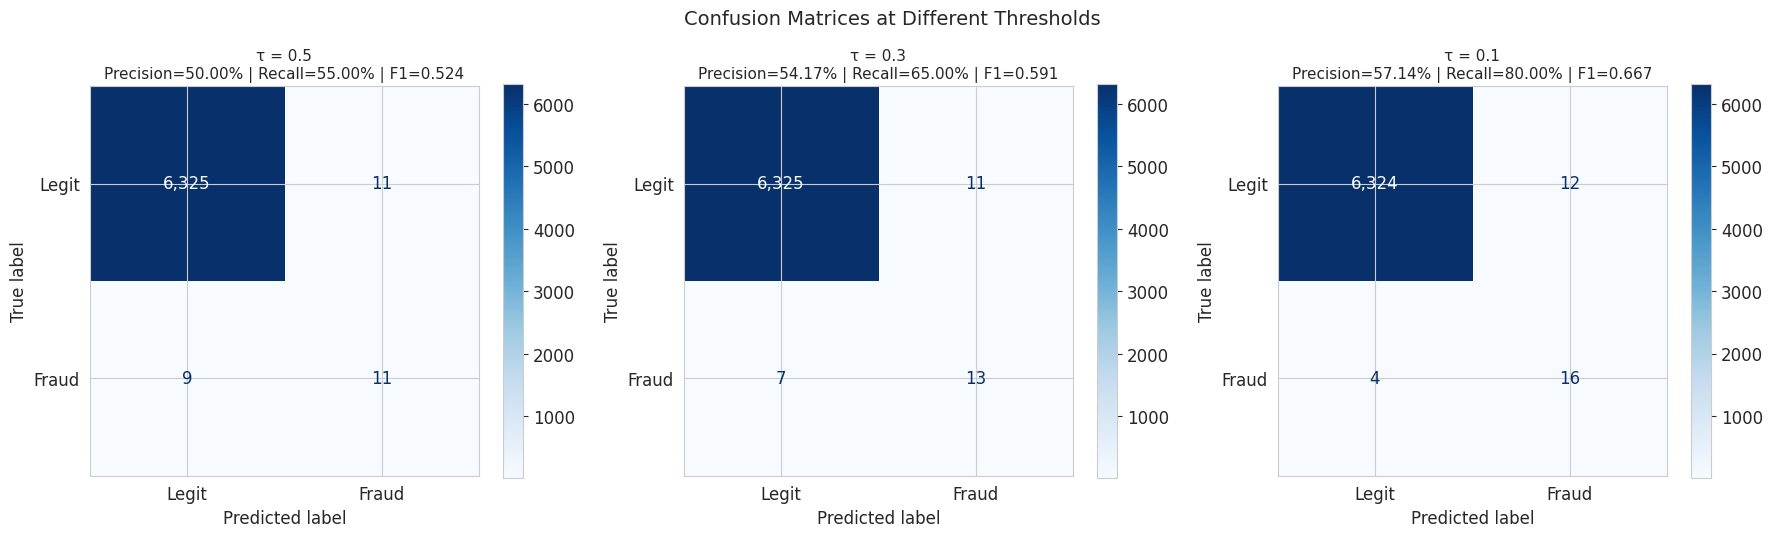


As τ decreases: Recall ↑ (catch more fraud), Precision ↓ (more false alarms)
This is the precision-recall tradeoff from lecture.


In [14]:
# Step 3: Compare confusion matrices at 3 different thresholds
# This is where you see the precision-recall tradeoff in action

thresholds_to_test = [0.5, 0.3, 0.1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, tau in enumerate(thresholds_to_test):
    y_pred_tau = (y_prob >= tau).astype(int)
    cm_tau = confusion_matrix(y_test, y_pred_tau)

    prec = precision_score(y_test, y_pred_tau, zero_division=0)
    rec = recall_score(y_test, y_pred_tau)
    f1 = f1_score(y_test, y_pred_tau)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_tau, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[i], cmap='Blues', values_format=',')
    axes[i].set_title(f'τ = {tau}\nPrecision={prec:.2%} | Recall={rec:.2%} | F1={f1:.3f}',
                      fontsize=11)

plt.suptitle('Confusion Matrices at Different Thresholds', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nAs τ decreases: Recall ↑ (catch more fraud), Precision ↓ (more false alarms)")
print("This is the precision-recall tradeoff from lecture.")

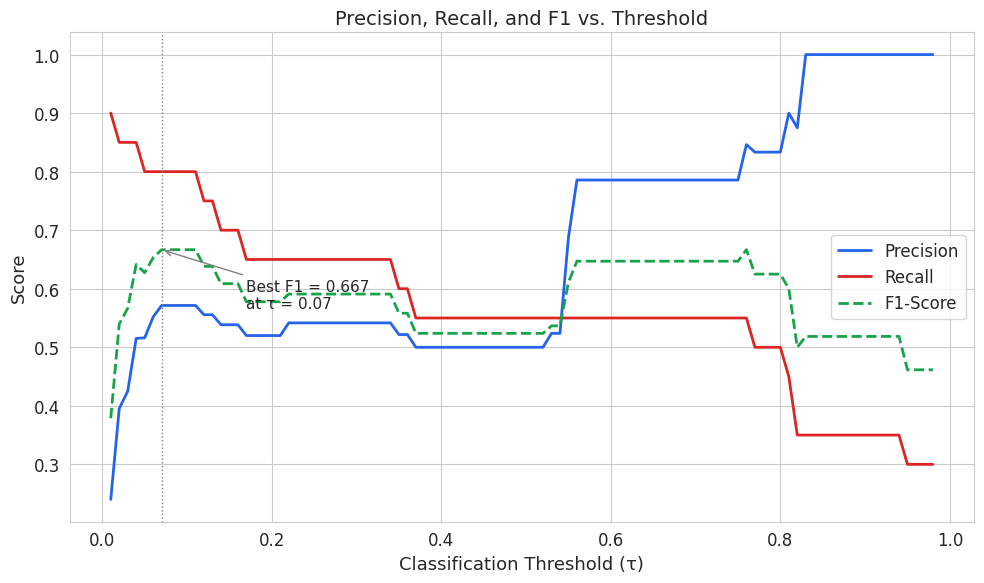


Optimal threshold for F1: τ = 0.07 (F1 = 0.667)

But remember from lecture: F1 assumes equal cost of FP and FN.
In fraud detection, you might prefer a lower τ to maximize Recall (catch more fraud).


In [15]:
# Step 4: Find the threshold that maximizes F1 for the fraud class

# Compute F1 at many thresholds
f1_scores = []
precision_scores = []
recall_scores = []
threshold_range = np.arange(0.01, 0.99, 0.01)

for tau in threshold_range:
    y_pred_tau = (y_prob >= tau).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_tau, zero_division=0))
    precision_scores.append(precision_score(y_test, y_pred_tau, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_tau, zero_division=0))

# Plot metrics vs threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_range, precision_scores, label='Precision', color='#2563eb', linewidth=2)
ax.plot(threshold_range, recall_scores, label='Recall', color='#dc2626', linewidth=2)
ax.plot(threshold_range, f1_scores, label='F1-Score', color='#16a34a', linewidth=2, linestyle='--')

best_tau = threshold_range[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
ax.axvline(x=best_tau, color='gray', linestyle=':', linewidth=1)
ax.annotate(f'Best F1 = {best_f1:.3f}\nat τ = {best_tau:.2f}',
            xy=(best_tau, best_f1), xytext=(best_tau + 0.1, best_f1 - 0.1),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Classification Threshold (τ)', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Precision, Recall, and F1 vs. Threshold', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nOptimal threshold for F1: τ = {best_tau:.2f} (F1 = {best_f1:.3f})")
print(f"\nBut remember from lecture: F1 assumes equal cost of FP and FN.")
print(f"In fraud detection, you might prefer a lower τ to maximize Recall (catch more fraud).")

In [17]:
# TODO: Find the threshold that flags approximately 500 transactions
# Hint: For each threshold, count how many transactions are flagged (y_prob >= tau)
# Then compute the Recall at that threshold

# Your code here:
max_investigations = 500

for tau in np.arange(0.01, 0.99, 0.01):
    n_flagged = (y_prob >= tau).sum()
    if n_flagged <= max_investigations:
        y_pred_capacity = (y_prob >= tau).astype(int)
        rec = recall_score(y_test, y_pred_capacity)
        prec = precision_score(y_test, y_pred_capacity, zero_division=0)
        print(f"τ = {tau:.2f} → {n_flagged} flagged | Recall = {rec:.2%} | Precision = {prec:.2%}")
        break

# TODO: Interpret — is this Recall acceptable for a fraud team?
# What would you recommend to the VP of Risk?

τ = 0.01 → 75 flagged | Recall = 90.00% | Precision = 24.00%


In [ ]:
!pip install streamlit scikit-learn pandas matplotlib localtunnel
!streamlit run streamlit_app.py &>/dev/null& npx localtunnel --port 8501

In [22]:
%%writefile streamlit_app.py
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.preprocessing import StandardScaler


st.set_page_config(page_title="Fraud Threshold Dashboard", layout="wide")
st.title("Fraud Detection Threshold Dashboard")
st.markdown(
    """
Interactive dashboard for threshold selection, confusion-matrix analysis,
cost-sensitive evaluation, and model comparison on the Credit Card Fraud dataset.
"""
)


# ------------------------------------------------------------
# CACHE DATA + MODEL TRAINING
# st.cache_data caches data loading/preprocessing.
# st.cache_resource caches trained models so slider changes rerun fast.
# ------------------------------------------------------------
@st.cache_data
def load_data():
    # Update path if needed
    df = pd.read_csv("creditcard.csv")

    X = df.drop("Class", axis=1)
    y = df["Class"]

    # Standardize Time and Amount only; PCA columns V1-V28 are already transformed
    X = X.copy()
    scaler = StandardScaler()
    X[["Time", "Amount"]] = scaler.fit_transform(X[["Time", "Amount"]])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    return X_train, X_test, y_train, y_test


@st.cache_resource
def train_models():
    X_train, X_test, y_train, y_test = load_data()

    log_reg = LogisticRegression(max_iter=1000, random_state=42)
    log_reg.fit(X_train, y_train)
    y_prob = log_reg.predict_proba(X_test)[:, 1]

    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )
    rf.fit(X_train, y_train)
    rf_prob = rf.predict_proba(X_test)[:, 1]

    return X_train, X_test, y_train, y_test, log_reg, y_prob, rf, rf_prob


X_train, X_test, y_train, y_test, log_reg, y_prob, rf, rf_prob = train_models()


# ------------------------------------------------------------
# SIDEBAR CONTROLS
# st.slider causes a full rerun whenever the user changes it.
# Because data/models are cached, the rerun is fast and only the metrics/plots update.
# ------------------------------------------------------------
st.sidebar.header("Controls")

threshold = st.sidebar.slider(
    "Classification Threshold",
    min_value=0.01,
    max_value=0.99,
    value=0.50,
    step=0.01
)

cost_fn = st.sidebar.number_input(
    "Cost of Missed Fraud (False Negative)",
    min_value=0.0,
    value=1000.0,
    step=50.0
)

cost_fp = st.sidebar.number_input(
    "Cost of False Alarm (False Positive)",
    min_value=0.0,
    value=10.0,
    step=1.0
)


# ------------------------------------------------------------
# METRIC HELPER
# Cost metric:
# total_cost = FN * cost_fn + FP * cost_fp
# FN = fraud we missed
# FP = legitimate transaction incorrectly flagged
# ------------------------------------------------------------
def evaluate_at_threshold(y_true, prob, threshold, cost_fn, cost_fp):
    y_pred = (prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    total_cost = (fn * cost_fn) + (fp * cost_fp)

    return {
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "total_cost": total_cost,
        "y_pred": y_pred
    }


results = evaluate_at_threshold(y_test, y_prob, threshold, cost_fn, cost_fp)


# ------------------------------------------------------------
# MAIN PANEL 1: THRESHOLD-BASED LOGISTIC REGRESSION VIEW
# ------------------------------------------------------------
st.header("1) Logistic Regression: Threshold + Cost-Sensitive Evaluation")

col1, col2, col3, col4 = st.columns(4)
col1.metric("Precision", f"{results['precision']:.4f}")
col2.metric("Recall", f"{results['recall']:.4f}")
col3.metric("F1-Score", f"{results['f1']:.4f}")
col4.metric("Total Dollar Cost", f"${results['total_cost']:,.2f}")

cm_col, info_col = st.columns([1.1, 1])

with cm_col:
    fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
    cm = np.array([
        [results["tn"], results["fp"]],
        [results["fn"], results["tp"]]
    ])
    im = ax_cm.imshow(cm, interpolation="nearest")
    ax_cm.set_title(f"Confusion Matrix @ Threshold = {threshold:.2f}")
    ax_cm.set_xlabel("Predicted Label")
    ax_cm.set_ylabel("True Label")
    ax_cm.set_xticks([0, 1])
    ax_cm.set_yticks([0, 1])
    ax_cm.set_xticklabels(["Legit (0)", "Fraud (1)"])
    ax_cm.set_yticklabels(["Legit (0)", "Fraud (1)"])

    for i in range(2):
        for j in range(2):
            ax_cm.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

    plt.tight_layout()
    st.pyplot(fig_cm)

with info_col:
    st.subheader("Counts")
    st.write(f"**True Negatives (TN):** {results['tn']:,}")
    st.write(f"**False Positives (FP):** {results['fp']:,}")
    st.write(f"**False Negatives (FN):** {results['fn']:,}")
    st.write(f"**True Positives (TP):** {results['tp']:,}")

    st.subheader("Cost Metric")
    st.write(
        f"""
**Formula:**
`Total Cost = (FN × cost_fn) + (FP × cost_fp)`

With your current settings:

- FN cost = **${cost_fn:,.2f}**
- FP cost = **${cost_fp:,.2f}**

So the dashboard computes:

**({results['fn']} × {cost_fn:,.2f}) + ({results['fp']} × {cost_fp:,.2f}) = ${results['total_cost']:,.2f}**
"""
    )


# ------------------------------------------------------------
# THRESHOLD SWEEP FOR COST + F1 CURVES
# ------------------------------------------------------------
threshold_grid = np.round(np.arange(0.01, 1.00, 0.01), 2)

sweep_records = []
for t in threshold_grid:
    r = evaluate_at_threshold(y_test, y_prob, t, cost_fn, cost_fp)
    sweep_records.append({
        "threshold": t,
        "precision": r["precision"],
        "recall": r["recall"],
        "f1": r["f1"],
        "total_cost": r["total_cost"],
        "fp": r["fp"],
        "fn": r["fn"],
    })

sweep_df = pd.DataFrame(sweep_records)

cost_min_idx = sweep_df["total_cost"].idxmin()
f1_max_idx = sweep_df["f1"].idxmax()

cost_min_row = sweep_df.loc[cost_min_idx]
f1_max_row = sweep_df.loc[f1_max_idx]

st.subheader("Threshold Tradeoff Curves")

curve_col1, curve_col2 = st.columns(2)

with curve_col1:
    fig_cost, ax_cost = plt.subplots(figsize=(7, 4))
    ax_cost.plot(sweep_df["threshold"], sweep_df["total_cost"], label="Dollar Cost")
    ax_cost.axvline(threshold, linestyle="--", label=f"Current Threshold = {threshold:.2f}")
    ax_cost.axvline(cost_min_row["threshold"], linestyle=":", label=f"Cost Min = {cost_min_row['threshold']:.2f}")
    ax_cost.set_title("Dollar Cost vs Threshold")
    ax_cost.set_xlabel("Threshold")
    ax_cost.set_ylabel("Total Cost")
    ax_cost.legend()
    plt.tight_layout()
    st.pyplot(fig_cost)

with curve_col2:
    fig_f1, ax_f1 = plt.subplots(figsize=(7, 4))
    ax_f1.plot(sweep_df["threshold"], sweep_df["f1"], label="F1-Score")
    ax_f1.axvline(threshold, linestyle="--", label=f"Current Threshold = {threshold:.2f}")
    ax_f1.axvline(f1_max_row["threshold"], linestyle=":", label=f"F1 Max = {f1_max_row['threshold']:.2f}")
    ax_f1.set_title("F1-Score vs Threshold")
    ax_f1.set_xlabel("Threshold")
    ax_f1.set_ylabel("F1")
    ax_f1.legend()
    plt.tight_layout()
    st.pyplot(fig_f1)

st.write(
    f"""
**Cost-minimizing threshold:** `{cost_min_row['threshold']:.2f}`
**Minimum total cost:** `${cost_min_row['total_cost']:,.2f}`

**F1-maximizing threshold:** `{f1_max_row['threshold']:.2f}`
**Maximum F1-score:** `{f1_max_row['f1']:.4f}`
"""
)


# ------------------------------------------------------------
# MAIN PANEL 2: MODEL COMPARISON
# PR-AUC is especially useful in imbalanced data because it focuses on
# performance for the positive class. ROC-AUC can still look strong even when
# the model performs poorly on rare fraud cases.
# ------------------------------------------------------------
st.header("2) Logistic Regression vs Random Forest")

roc_lr = roc_auc_score(y_test, y_prob)
roc_rf = roc_auc_score(y_test, rf_prob)

prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf_prob)

pr_auc_lr = auc(rec_lr, prec_lr)
pr_auc_rf = auc(rec_rf, prec_rf)

metric_col1, metric_col2 = st.columns(2)
with metric_col1:
    st.subheader("Logistic Regression")
    st.write(f"**ROC-AUC:** {roc_lr:.4f}")
    st.write(f"**PR-AUC:** {pr_auc_lr:.4f}")

with metric_col2:
    st.subheader("Random Forest")
    st.write(f"**ROC-AUC:** {roc_rf:.4f}")
    st.write(f"**PR-AUC:** {pr_auc_rf:.4f}")

plot_col1, plot_col2 = st.columns(2)

with plot_col1:
    fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

    fig_roc, ax_roc = plt.subplots(figsize=(7, 5))
    ax_roc.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_lr:.4f})")
    ax_roc.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_rf:.4f})")
    ax_roc.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
    ax_roc.set_title("ROC Curve Comparison")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend()
    plt.tight_layout()
    st.pyplot(fig_roc)

with plot_col2:
    fig_pr, ax_pr = plt.subplots(figsize=(7, 5))
    ax_pr.plot(rec_lr, prec_lr, label=f"Logistic Regression (PR-AUC = {pr_auc_lr:.4f})")
    ax_pr.plot(rec_rf, prec_rf, label=f"Random Forest (PR-AUC = {pr_auc_rf:.4f})")
    ax_pr.set_title("Precision-Recall Curve Comparison")
    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.legend()
    plt.tight_layout()
    st.pyplot(fig_pr)


# ------------------------------------------------------------
# OPTIONAL THRESHOLD TABLE
# ------------------------------------------------------------
with st.expander("Show threshold sweep table"):
    st.dataframe(sweep_df, use_container_width=True)


# ------------------------------------------------------------
# INTERPRETATION GUIDE
# ------------------------------------------------------------
st.header("How to Interpret This Dashboard")
st.markdown(
    """
- As you drag the threshold **down** toward `0.01`, the model flags more transactions as fraud.
  That usually **increases Recall** and **decreases Precision**. You catch more fraud, but you also create more false alarms.

- As you drag the threshold **up** toward `0.99`, the model becomes stricter.
  That usually **increases Precision** and **decreases Recall**. You reduce false alarms, but you miss more actual fraud.

- The **dollar-cost curve** depends on your chosen business assumptions:
  `Total Cost = (FN × cost_fn) + (FP × cost_fp)`

- If missed fraud is very expensive, the cost-minimizing threshold often moves **lower**, because the dashboard prefers catching more fraud even if false positives rise.

- If false alarms are expensive, the cost-minimizing threshold may move **higher**, because the dashboard prefers fewer unnecessary investigations.

- The **cost-minimizing operating point** is the threshold where the total dollar-cost curve is lowest.

- The **F1-maximizing operating point** is the threshold where the F1 curve is highest.
  These two points are often **not the same**, because F1 balances Precision and Recall mathematically, while the cost curve reflects your real business penalties.

- In heavily imbalanced fraud data, **PR-AUC is often more informative than ROC-AUC**, because PR-AUC focuses directly on how well the model identifies the rare positive class.
"""
)

Writing streamlit_app.py
